# Imports and definitions

In [1]:
# imports
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from numpy import cos, sin, arctan, sqrt, exp
from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.colors import to_rgba
from scipy.integrate import simpson
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.cm as cm
from tqdm import tqdm
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [3]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# Fetch data

In [4]:
sd = SimDir("../simulations/Merger_CCZ4_M=0.5,0.5-T=0.05,0.05-alpha=0,0.5pi-x0=8_h=3")
ts = sd.timeseries
gf = sd.gf

hor  = sd.horizons
hor1 = hor.get_apparent_horizon(1)
hor2 = hor.get_apparent_horizon(2)
muls = sd.multipoles

# Puncture movement

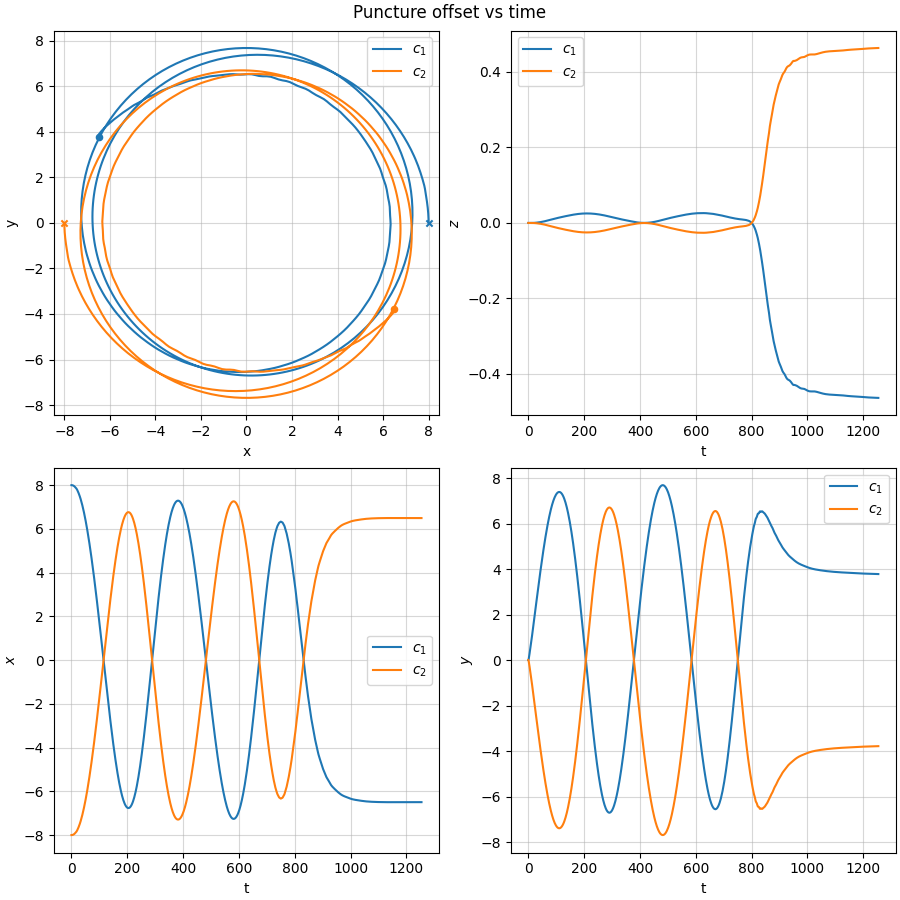

In [5]:
c1_x = hor1.get_ah_property("centroid_x")
c1_y = hor1.get_ah_property("centroid_y")
c1_z = hor1.get_ah_property("centroid_z")

c2_x = hor2.get_ah_property("centroid_x")
c2_y = hor2.get_ah_property("centroid_y")
c2_z = hor2.get_ah_property("centroid_z")


fig, ax = plt.subplots(2, 2, figsize=(9,9), constrained_layout=True)
plt.suptitle("Puncture offset vs time")


ax[0,0].plot(c1_x.values, c1_y.values, color="C0", label=r"$c_1$")
ax[0,0].plot(c2_x.values, c2_y.values, color="C1", label=r"$c_2$")

ax[0,0].scatter([c1_x.values[0]],   [c1_y.values[0]],   color="C0", marker="x", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[0]],   [c2_y.values[0]],   color="C1", marker="x", s=20, zorder=10)
ax[0,0].scatter([c1_x.values[-1]],  [c1_y.values[-1]],  color="C0", marker="o", s=20, zorder=10)
ax[0,0].scatter([c2_x.values[-1]],  [c2_y.values[-1]],  color="C1", marker="o", s=20, zorder=10)

ax[0,0].set_aspect('equal', adjustable='datalim')
ax[0,0].grid(alpha=0.5, zorder=-10)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("y")
ax[0,0].legend()


ax[0,1].plot(c1_z.t, c1_z.values, color="C0", label=r"$c_1$")
ax[0,1].plot(c2_z.t, c2_z.values, color="C1", label=r"$c_2$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_ylabel(r"$z$")
ax[0,1].legend();


ax[1,0].plot(c1_x.t, c1_x.values, color="C0", label=r"$c_1$")
ax[1,0].plot(c2_x.t, c2_x.values, color="C1", label=r"$c_2$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_ylabel(r"$x$")
ax[1,0].legend();


ax[1,1].plot(c1_y.t, c1_y.values, color="C0", label=r"$c_1$")
ax[1,1].plot(c2_y.t, c2_y.values, color="C1", label=r"$c_2$")

ax[1,1].grid(alpha=0.5)
ax[1,1].set_xlabel("t")
ax[1,1].set_ylabel(r"$y$")
ax[1,1].legend();

# Global quantities

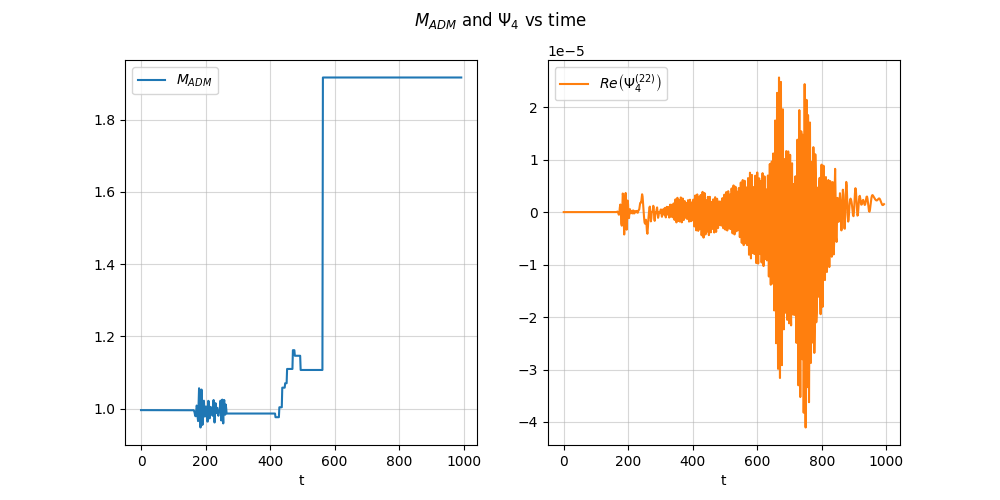

In [6]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$M_{ADM}$ and $\Psi_4$ vs time")

R = 240

M = hor[5,6].adm_energy
psi4_22 = muls["Psi4"][R][(2,2)]

ax1.plot(M.t, M.y, color="C0", label=r"$M_{ADM}$")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.legend()

ax2.plot(psi4_22.t, psi4_22.y.real, color="C1", label=r"$Re \left(\Psi_4^{(22)} \right)$")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.legend();

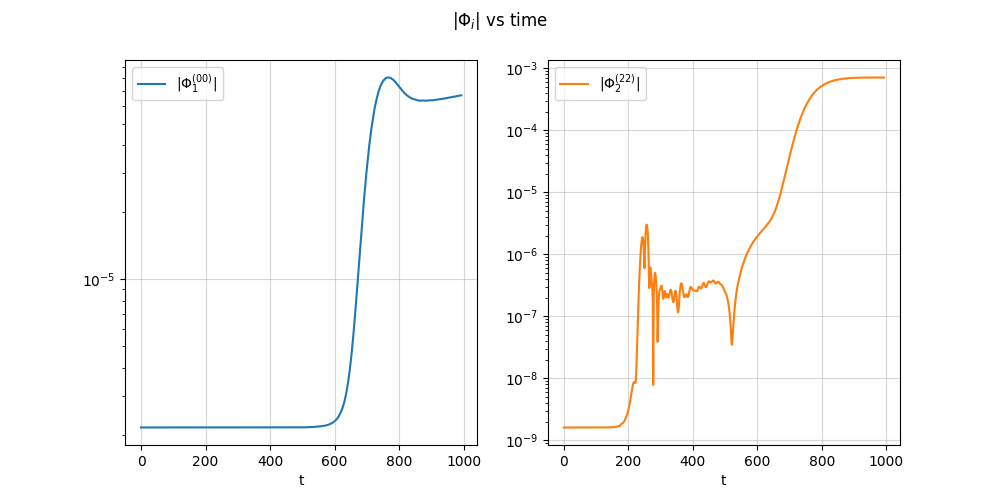

In [7]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,5))
plt.suptitle(r"$|\Phi_i|$ vs time")

R = 240

Phi1_00 = muls["Phi1"][R][(0,0)]
Phi2_22 = muls["Phi2"][R][(2,2)]

ax1.plot(Phi1_00.t, sqrt(Phi1_00.y.real**2 + Phi1_00.y.imag**2), label=r"$|\Phi_1^{(00)}|$", color="C0")

ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_yscale("log")
ax1.legend()

ax2.plot(Phi2_22.t, sqrt(Phi2_22.y.real**2 + Phi2_22.y.imag**2), label=r"$|\Phi_2^{(22)}|$", color="C1")

ax2.grid(alpha=0.5)
ax2.set_xlabel("t")
ax2.set_yscale("log")
ax2.legend();

# E.M. radiation

In [ ]:
# output frequency is every 128 iterations
n = 180
iteration = 128*n

Ey_gf = gf.x["Ey"].get_iteration(iteration).get_level(0)
coor_gf = Ey_gf.grid.coordinates_1d[0]
Ey_2 = Ey_gf.data

Ez_gf = gf.x["Ez"].get_iteration(iteration).get_level(0)
coor_gf = Ez_gf.grid.coordinates_1d[0]
Ez_2 = Ez_gf.data

By_gf = gf.x["By"].get_iteration(iteration).get_level(0)
coor_gf = By_gf.grid.coordinates_1d[0]
By_2 = By_gf.data

Bz_gf = gf.x["Bz"].get_iteration(iteration).get_level(0)
coor_gf = Bz_gf.grid.coordinates_1d[0]
Bz_2 = Bz_gf.data

[-258. -255. -252. -249. -246. -243. -240. -237. -234. -231. -228. -225.
 -222. -219. -216. -213. -210. -207. -204. -201. -198. -195. -192. -189.
 -186. -183. -180. -177. -174. -171. -168. -165. -162. -159. -156. -153.
 -150. -147. -144. -141. -138. -135. -132. -129. -126. -123. -120. -117.
 -114. -111. -108. -105. -102.  -99.  -96.  -93.  -90.  -87.  -84.  -81.
  -78.  -75.  -72.  -69.  -66.  -63.  -60.  -57.  -54.  -51.  -48.  -45.
  -42.  -39.  -36.  -33.  -30.  -27.  -24.  -21.  -18.  -15.  -12.   -9.
   -6.   -3.    0.    3.    6.    9.   12.   15.   18.   21.   24.   27.
   30.   33.   36.   39.   42.   45.   48.   51.   54.   57.   60.   63.
   66.   69.   72.   75.   78.   81.   84.   87.   90.   93.   96.   99.
  102.  105.  108.  111.  114.  117.  120.  123.  126.  129.  132.  135.
  138.  141.  144.  147.  150.  153.  156.  159.  162.  165.  168.  171.
  174.  177.  180.  183.  186.  189.  192.  195.  198.  201.  204.  207.
  210.  213.  216.  219.  222.  225.  228.  231.  2

In [ ]:
# crop data
# might require manual intervention due to time-dependent meshes
imin = 130
imax = -1

coor = coor_gf[imin:imax]

Ey = Ey_2[imin:imax]
Ez = Ez_2[imin:imax]
By = By_2[imin:imax]
Bz = Bz_2[imin:imax]

print(coor)

[132. 135. 138. 141. 144. 147. 150. 153. 156. 159. 162. 165. 168. 171.
 174. 177. 180. 183. 186. 189. 192. 195. 198. 201. 204. 207. 210. 213.
 216. 219. 222. 225. 228. 231. 234. 237. 240. 243. 246. 249. 252. 255.]


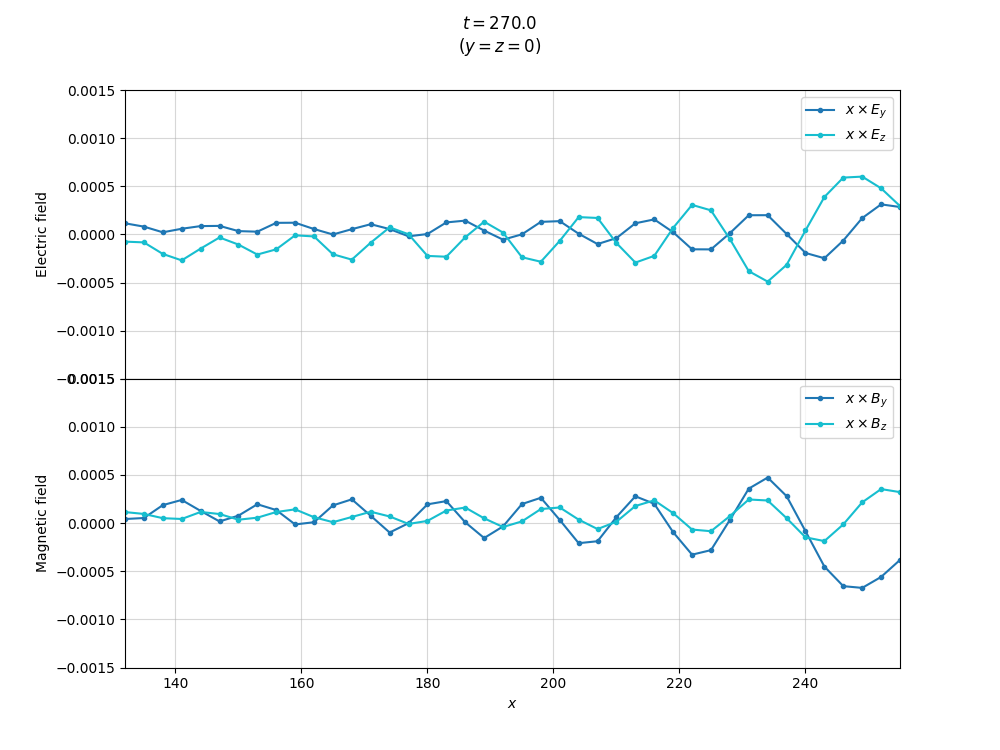

In [34]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10,7.5), sharex=True, gridspec_kw={'hspace': 0})

plt.suptitle(f"$t = {Ey_gf.time}$\n$(y=z=0)$")

# plot the electric field
ax1.plot(coor, coor*Ey, color="C0", label=r"$x \times E_y$", marker=".")
ax1.plot(coor, coor*Ez, color="C9", label=r"$x \times E_z$", marker=".")

ax1.grid(alpha=0.5)
ax1.set_ylabel("Electric field")
ax1.set_ylim((-0.0015,0.0015))
ax1.legend()

# plot the magnetic field
ax2.plot(coor, coor*By, color="C0", label=r"$x \times B_y$", marker=".")
ax2.plot(coor, coor*Bz, color="C9", label=r"$x \times B_z$", marker=".")

ax2.grid(alpha=0.5)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel("Magnetic field")
ax2.set_xlim((min(coor),max(coor)))
ax2.set_ylim((-0.0015,0.0015))
ax2.legend();

# Sketches

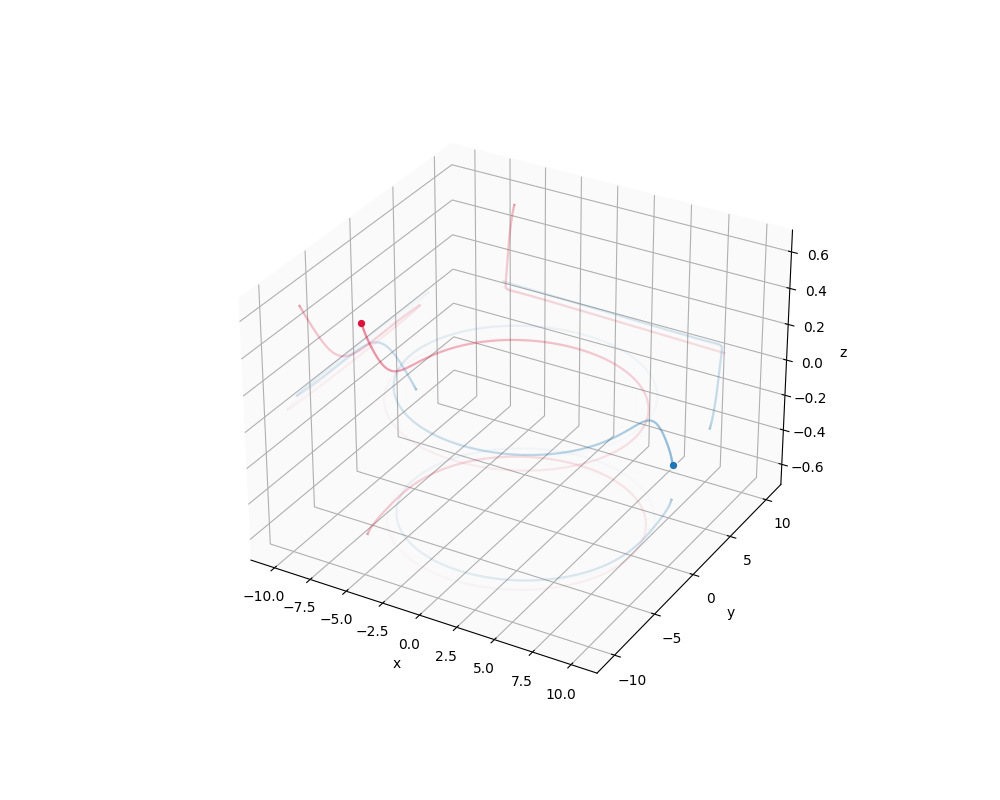

In [ ]:
def get_global_limits(series1, series2, buffer_pct=0.2):
    """Calculates min/max across both bodies to set the bounding box."""
    combined = np.concatenate([series1, series2])
    d_min, d_max = np.min(combined), np.max(combined)
    span = d_max - d_min
    return d_min - (span * buffer_pct), d_max + (span * buffer_pct)

def plot_fading_trail(ax, x, y, z, color, limits, exponent=4, main_alpha=1, proj_alpha=0.5):
    """Plots a 3D trail and its 3 plane projections with exponential fade."""
    n_points = len(x)
    # Generate the exponential alpha mask
    alpha_mask = np.linspace(0, 1, n_points - 1)**exponent

    # Define the 4 paths: Main, XY Floor, YZ Wall, XZ Wall
    x_lim_min, _, y_lim_max, z_lim_min, _ = limits

    paths = [
        (x, y, z, main_alpha),               # Main 3D Trail
        (x, y, np.full_like(z, z_lim_min), proj_alpha),  # XY Projection
        (np.full_like(x, x_lim_min), y, z, proj_alpha),  # YZ Projection
        (x, np.full_like(y, y_lim_max), z, proj_alpha)   # XZ Projection
    ]

    for px, py, pz, max_a in paths:
        points = np.array([px, py, pz]).T.reshape(-1, 1, 3)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        rgba = np.zeros((len(segments), 4))
        rgba[:] = to_rgba(color)
        rgba[:, 3] = alpha_mask * max_a

        lc = Line3DCollection(segments, colors=rgba, lw=1.2 if max_a < 0.5 else 1.6)
        ax.add_collection3d(lc)

# --- 2. Main Plotting Logic ---

# Calculate global limits using both bodies
x_lims = get_global_limits(c1_x.values, c2_x.values)
y_lims = get_global_limits(c1_y.values, c2_y.values)
z_lims = get_global_limits(c1_z.values, c2_z.values)
all_limits = (x_lims[0], x_lims[1], y_lims[1], z_lims[0], z_lims[1]) # x_min, x_max, y_max, z_min, z_max

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Body 1 (Blue)
plot_fading_trail(ax, c1_x.values, c1_y.values, c1_z.values, 'C0', all_limits)
ax.scatter(c1_x.values[-1], c1_y.values[-1], c1_z.values[-1], color='C0', s=40, edgecolors='white', zorder=20)

# Plot Body 2 (Red)
plot_fading_trail(ax, c2_x.values, c2_y.values, c2_z.values, 'crimson', all_limits)
ax.scatter(c2_x.values[-1], c2_y.values[-1], c2_z.values[-1], color='crimson', s=40, edgecolors='white', zorder=20)

# Final Styling
ax.set_xlim(x_lims)
ax.set_ylim(y_lims)
ax.set_zlim(z_lims)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, linestyle='--', alpha=0.3)

# Pane styling for depth
ax.xaxis.set_pane_color((0.98, 0.98, 0.98, 1.0))
ax.yaxis.set_pane_color((0.98, 0.98, 0.98, 1.0))
ax.zaxis.set_pane_color((0.98, 0.98, 0.98, 1.0))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z");

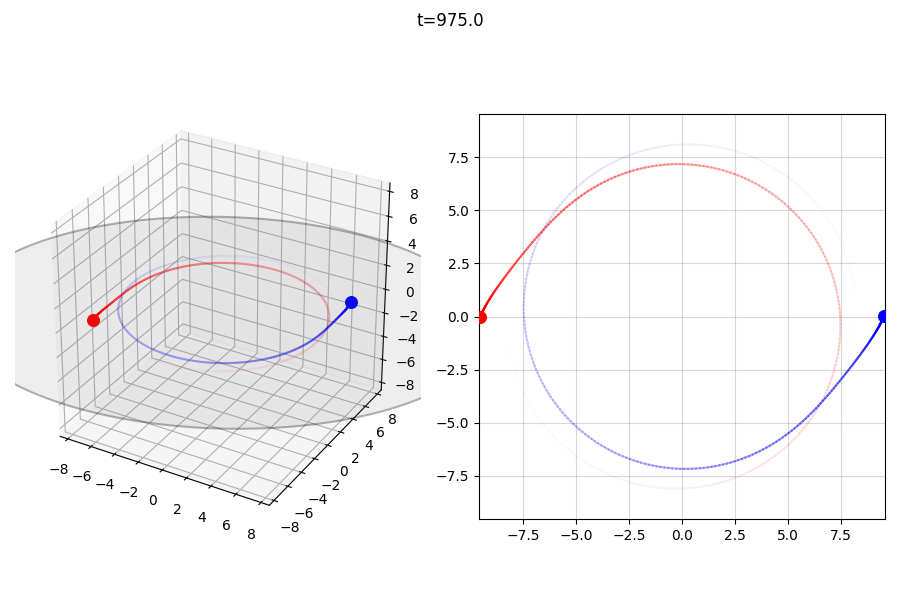

In [ ]:
# data
t = c1_x.t

r1 = np.vstack([
    c1_x.values,
    c1_y.values,
    c1_z.values
]).T

r2 = np.vstack([
    c2_x.values,
    c2_y.values,
    c2_z.values
]).T

# snapshot index
time_index = 650  # last time step to show
trail      = 420  # how many dots to use as trail
window     = 20   # nº of points to average out and define the orbital plane

# create plot
fig = plt.figure(figsize=(9,6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122)
plt.suptitle(f"t={t[time_index]}")

# ainda tenho que perceber esta gaita aqui
# e se fazer time average para o plano orbital faz sentido uma vez que ele precessa...
# em particular tenho que retirar o angulo dele daqui

start = max(0, time_index - trail)
i0 = max(0, time_index - window)

rel_r = r1[i0:time_index] - r2[i0:time_index]
rel_v = np.gradient(rel_r, axis=0)

h = np.mean(np.cross(rel_r, rel_v), axis=0)
h = h / np.linalg.norm(h)

u = rel_r[-1] / np.linalg.norm(rel_r[-1])
v = np.cross(h, u)
v = v / np.linalg.norm(v)

r1_2d = np.vstack([r1 @ u, r1 @ v]).T
r2_2d = np.vstack([r2 @ u, r2 @ v]).T

# ================
# left plot
# ================

# trails
for j in range(start, time_index-1):
    alpha = ((j-start)/trail)**3

    ax1.plot(r1[j:j+2,0], r1[j:j+2,1], r1[j:j+2,2], color="blue", alpha=alpha)
    ax1.plot(r2[j:j+2,0], r2[j:j+2,1], r2[j:j+2,2], color="red",  alpha=alpha)

# current positions
ax1.scatter(*r1[time_index], color="blue", s=70)
ax1.scatter(*r2[time_index], color="red", s=70)

# orbital plane
radius = np.linalg.norm(rel_r[-1])

theta = np.linspace(0, 2*np.pi, 200)

circle = np.outer(np.cos(theta), u) + np.outer(np.sin(theta), v)
circle = radius * circle

ax1.plot(        circle[:,0], circle[:,1], circle[:,2], color="black", alpha=0.3)  # outline
ax1.plot_trisurf(circle[:,0], circle[:,1], circle[:,2], color="gray",  alpha=0.1)  # fill

# fancy up plot
max_range = np.max(np.abs(np.vstack([r1, r2])))
ax1.set_xlim(-max_range, max_range)
ax1.set_ylim(-max_range, max_range)
ax1.set_zlim(-max_range, max_range)

ax1.set_box_aspect([1,1,1])

# ================
# right plot
# ================

# trail
# nota: estes trails nao estao a ser projetados no plano orbital
for j in range(start, time_index-1):
    alpha = ((j-start)/trail)**3

    ax2.plot(r1_2d[j:j+2,0], r1_2d[j:j+2,1], color="blue", alpha=alpha, zorder=10)
    ax2.plot(r2_2d[j:j+2,0], r2_2d[j:j+2,1], color="red",  alpha=alpha, zorder=10)

# current positions
ax2.scatter(r1_2d[time_index,0], r1_2d[time_index,1], color="blue", s=70, zorder=10)
ax2.scatter(r2_2d[time_index,0], r2_2d[time_index,1], color="red",  s=70, zorder=10)

# fancy up the plot
lim = np.max(np.abs(np.vstack([r1_2d, r2_2d])))  # este limite nao esta a ser muito bem calculado
ax2.set_aspect("equal")
ax2.grid(alpha=0.5, zorder=-10)
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)

plt.tight_layout();